# Motor control model - Comparison of different architectures

In [2]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../')

import nn_fncs
mat_data = nn_fncs.read_mat_workspace('./Data/motorModelControl1.mat') # data sampled at 1e-3s

motor_p = mat_data.get('motor_p_out')

input_data = motor_p[:,:, 1:4]
output_data = motor_p[:,:, 0]

# print input and output data shapes
print(f'input_data shape: {input_data.shape}')  # (num_trajectories, num_time_steps, PID errors)
print(f'output_data shape: {output_data.shape}')  # (num_trajectories, num_time_steps, u signals)

input_data shape: (200, 5000, 3)
output_data shape: (200, 5000)


In [3]:
# Split data into training and validation sets
import numpy as np
train_ratio = 0.8
train_size = int(input_data.shape[0] * train_ratio)

train_input = input_data[:train_size].reshape(-1, input_data.shape[2])
train_output = output_data[:train_size].reshape(-1, 1)
val_input = input_data[train_size:].reshape(-1, input_data.shape[2])
val_output = output_data[train_size:].reshape(-1, 1)

# Max Abs values before scaling
print(f'Max abs input before scaling: {np.max(np.abs(train_input), axis=0)}')
print(f'Max abs output before scaling: {np.max(np.abs(train_output), axis=0)}')

# # Standardize the data
from sklearn.preprocessing import StandardScaler
input_scaler = StandardScaler()
output_scaler = StandardScaler()

train_input = input_scaler.fit_transform(train_input)
train_output = output_scaler.fit_transform(train_output)
val_input = input_scaler.transform(val_input)
val_output = output_scaler.transform(val_output)

# Print max abs values after scaling
print(f'Max abs input after scaling: {np.max(np.abs(train_input), axis=0)}')
print(f'Max abs output after scaling: {np.max(np.abs(train_output), axis=0)}')

# Create datasets and dataloaders
import torch
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(torch.tensor(train_input, dtype=torch.float32),
                              torch.tensor(train_output, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(val_input, dtype=torch.float32),
                            torch.tensor(val_output, dtype=torch.float32))

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Max abs input before scaling: [1596.48954051   50.10829083   50.10829083]
Max abs output before scaling: [12.]
Max abs input after scaling: [17.97084429 23.74342507 23.74342507]
Max abs output after scaling: [7.60145786]


In [ ]:
# Save the scalers for future use
import joblib

# joblib.dump(input_scaler, './ControlScalers/input_scaler.pkl')
# joblib.dump(output_scaler, './ControlScalers/output_scaler.pkl')

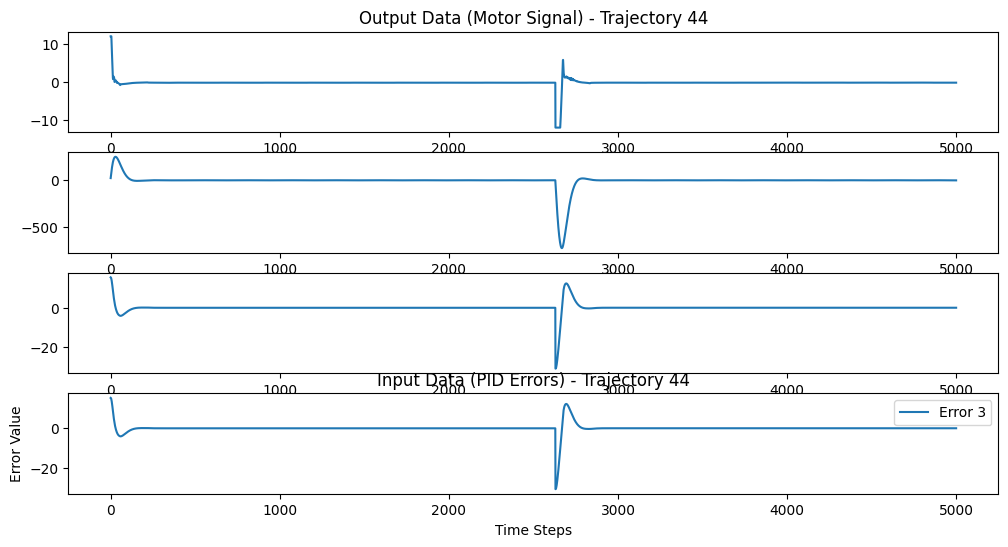

In [ ]:
# Display random trajectory input and output data in a graph
from random import randint
import matplotlib.pyplot as plt

# Select a random trajectory index
random_trajectory = randint(0, input_data.shape[0] - 1)

plt.figure(figsize=(12, 6))
plt.subplot(4, 1, 1)
plt.plot(output_data[random_trajectory, :], label='Motor Output Signal')
plt.title(f'Output Data (Motor Signal) - Trajectory {random_trajectory}')
plt.subplot(4, 1, 2)
plt.plot(input_data[random_trajectory, :, 0], label='Error 1')
plt.subplot(4, 1, 3)
plt.plot(input_data[random_trajectory, :, 1], label='Error 2')
plt.subplot(4, 1, 4)
plt.plot(input_data[random_trajectory, :, 2], label='Error 3')
plt.title(f'Input Data (PID Errors) - Trajectory {random_trajectory}')
plt.xlabel('Time Steps')
plt.ylabel('Error Value')   
plt.legend()

In [ ]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 10
dropout_rate = 0.5
class ControlModel(nn.Module):
    def __init__(self, input_size=3, output_size=1, n_neurons=n_neurons):  
        super(ControlModel, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, output_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, errors):
        dx = F.relu(self.fc1(errors))
        dx = self.dropout(dx)
        dx = F.relu(self.fc2(dx))
        dx = self.output(dx)
        return dx

# Create the model
model = ControlModel()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

ControlModel(
  (fc1): Linear(in_features=3, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 161


In [ ]:
# One step training
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_training(model, criterion, optimizer, input_data, target_data):
    model.train()
    with torch.set_grad_enabled(True):
        # Forward pass
        pred = model(input_data)  # Integrate over a small time step
        loss = criterion(pred, target_data)  # Compare with the next state
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    r2 = r2_score(pred, target_data)
    return pred, loss, r2

In [ ]:
# One step validation
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_validation(model, criterion, input_data, target_data):
    model.eval()
    with torch.no_grad():
        # Forward pass
        pred = model(input_data)  # Integrate over a small time step
        loss = criterion(pred, target_data)  # Compare with the next state
    r2 = r2_score(pred, target_data)
    return pred, loss, r2

In [ ]:
# Test the one_step_training function
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
input_data, target_data = next(iter(train_loader))
pred, loss, r2 = one_step_training(model, criterion, optimizer, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')


Test Loss: 0.6342567205429077, R2 Score: -0.039185523986816406


In [101]:
# Complete training loop
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 500
epoch_update = 5
with tqdm(total=n_epochs) as pbar:
    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        train_r2s = []
        for input_data, target_data in train_loader:
            pred, loss, r2 = one_step_training(model, criterion, optimizer, input_data, target_data)
            train_losses.append(loss.item())
            train_r2s.append(r2.item())
        
        model.eval()
        val_losses = []
        val_r2s = []
        with torch.no_grad():
            for input_data, target_data in val_loader:
                pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
                val_losses.append(loss.item())
                val_r2s.append(r2.item())
        
        if (epoch + 1) % epoch_update == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, '
                f'Train Loss: {sum(train_losses)/len(train_losses):.4f}, '
                f'Train R2: {sum(train_r2s)/len(train_r2s):.4f}, '
                f'Val Loss: {sum(val_losses)/len(val_losses):.4f}, '
                f'Val R2: {sum(val_r2s)/len(val_r2s):.4f}')
            pbar.update(epoch_update)

  1%|          | 5/500 [01:39<2:44:28, 19.94s/it]

Epoch 5/500, Train Loss: 0.0987, Train R2: 0.8880, Val Loss: 0.1271, Val R2: -inf


  2%|▏         | 10/500 [03:21<2:44:37, 20.16s/it]

Epoch 10/500, Train Loss: 0.0934, Train R2: 0.8920, Val Loss: 0.1382, Val R2: -inf


  3%|▎         | 15/500 [05:01<2:42:17, 20.08s/it]

...

Epoch 490/500, Train Loss: 0.0694, Train R2: 0.9196, Val Loss: 0.1013, Val R2: -inf


 99%|█████████▉| 495/500 [4:29:41<01:37, 19.43s/it]

Epoch 495/500, Train Loss: 0.0689, Train R2: 0.9180, Val Loss: 0.1289, Val R2: -inf


100%|██████████| 500/500 [4:31:17<00:00, 32.56s/it]

Epoch 500/500, Train Loss: 0.0692, Train R2: 0.9184, Val Loss: 0.1104, Val R2: -inf


In [102]:
# Save trained model
torch.save(model.state_dict(), "control_model_v1.pth")

In [103]:
# Test model with random u_signals validation data

id = randint(0, val_input.shape[0] - 1)
input_data = torch.tensor(val_input, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(val_output, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

Test Loss: 0.11043968796730042, R2 Score: 0.9326614141464233


In [ ]:
# Plot target vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(target_data[:1000].cpu().numpy(), label='True Values')
plt.plot(pred[:1000].cpu().numpy(), label='Predicted')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()

In [105]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 32
class ControlModelv2(nn.Module):
    def __init__(self, input_size=3, output_size=1, n_neurons=n_neurons):  
        super(ControlModelv2, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, output_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, errors):
        dx = F.relu(self.fc1(errors))
        dx = self.dropout(dx)
        dx = F.relu(self.fc2(dx))
        dx = self.output(dx)
        return dx

# Create the model
model = ControlModelv2()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

ControlModelv2(
  (fc1): Linear(in_features=3, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 1217


In [106]:
# Complete training loop
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 500
epoch_update = 5
with tqdm(total=n_epochs) as pbar:
    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        train_r2s = []
        for input_data, target_data in train_loader:
            pred, loss, r2 = one_step_training(model, criterion, optimizer, input_data, target_data)
            train_losses.append(loss.item())
            train_r2s.append(r2.item())
        
        model.eval()
        val_losses = []
        val_r2s = []
        with torch.no_grad():
            for input_data, target_data in val_loader:
                pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
                val_losses.append(loss.item())
                val_r2s.append(r2.item())
        
        if (epoch + 1) % epoch_update == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, '
                f'Train Loss: {sum(train_losses)/len(train_losses):.4f}, '
                f'Train R2: {sum(train_r2s)/len(train_r2s):.4f}, '
                f'Val Loss: {sum(val_losses)/len(val_losses):.4f}, '
                f'Val R2: {sum(val_r2s)/len(val_r2s):.4f}')
            pbar.update(epoch_update)

  0%|          | 0/500 [00:00<?, ?it/s]

  1%|          | 5/500 [01:45<2:53:58, 21.09s/it]

Epoch 5/500, Train Loss: 0.0605, Train R2: 0.9310, Val Loss: 0.0692, Val R2: -inf


  2%|▏         | 10/500 [03:30<2:51:53, 21.05s/it]

Epoch 10/500, Train Loss: 0.0487, Train R2: 0.9436, Val Loss: 0.0588, Val R2: -inf


...

Epoch 490/500, Train Loss: 0.0294, Train R2: 0.9638, Val Loss: 0.0567, Val R2: -inf


 99%|█████████▉| 495/500 [3:47:33<08:27, 101.53s/it]

Epoch 495/500, Train Loss: 0.0289, Train R2: 0.9644, Val Loss: 0.0510, Val R2: -inf


100%|██████████| 500/500 [3:56:37<00:00, 28.39s/it] 

Epoch 500/500, Train Loss: 0.0287, Train R2: 0.9644, Val Loss: 0.0508, Val R2: -inf


In [107]:
# Save trained model
torch.save(model.state_dict(), "control_model_v2.pth")

In [ ]:
# Test model with random u_signals validation data

id = randint(0, val_input.shape[0] - 1)
input_data = torch.tensor(val_input, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(val_output, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

Test Loss: 0.050814177840948105, R2 Score: 0.969016969203949


In [ ]:
# Test model with random u_signals validation data

id = randint(0, val_input.shape[0] - 1)
input_data = torch.tensor(val_input, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(val_output, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

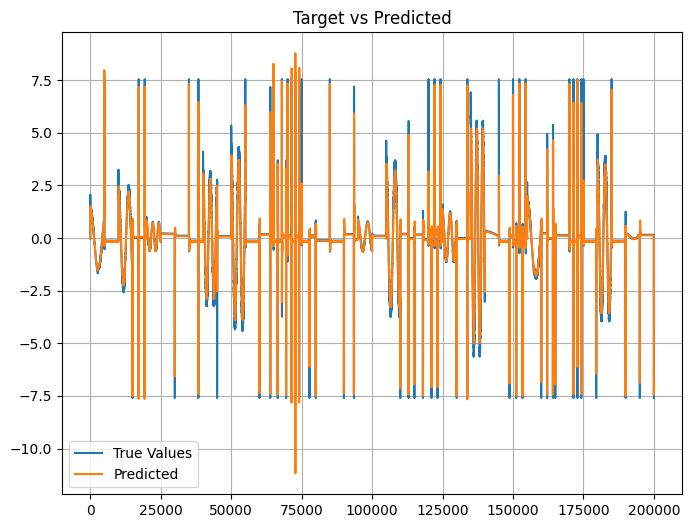

In [109]:
# Plot target vs predicted
plt.figure(figsize=(8, 6))
plt.plot(target_data.cpu().numpy(), label='True Values')
plt.plot(pred.cpu().numpy(), label='Predicted')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()

In [110]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 10
class ControlModelv3(nn.Module):
    def __init__(self, input_size=3, output_size=1, n_neurons=n_neurons):  
        super(ControlModelv3, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, n_neurons)
        self.fc4 = nn.Linear(n_neurons, n_neurons)
        self.fc5 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, output_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, errors):
        dx = F.relu(self.fc1(errors))
        dx = self.dropout(dx)
        dx = F.relu(self.fc2(dx))
        dx = F.relu(self.fc3(dx))
        dx = F.relu(self.fc4(dx))
        dx = F.relu(self.fc5(dx))
        dx = self.output(dx)
        return dx

# Create the model
model = ControlModelv3()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

ControlModelv3(
  (fc1): Linear(in_features=3, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=10, bias=True)
  (fc4): Linear(in_features=10, out_features=10, bias=True)
  (fc5): Linear(in_features=10, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 491


In [111]:
# Complete training loop
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 500
epoch_update = 5
with tqdm(total=n_epochs) as pbar:
    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        train_r2s = []
        for input_data, target_data in train_loader:
            pred, loss, r2 = one_step_training(model, criterion, optimizer, input_data, target_data)
            train_losses.append(loss.item())
            train_r2s.append(r2.item())
        
        model.eval()
        val_losses = []
        val_r2s = []
        with torch.no_grad():
            for input_data, target_data in val_loader:
                pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
                val_losses.append(loss.item())
                val_r2s.append(r2.item())
        
        if (epoch + 1) % epoch_update == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, '
                f'Train Loss: {sum(train_losses)/len(train_losses):.4f}, '
                f'Train R2: {sum(train_r2s)/len(train_r2s):.4f}, '
                f'Val Loss: {sum(val_losses)/len(val_losses):.4f}, '
                f'Val R2: {sum(val_r2s)/len(val_r2s):.4f}')
            pbar.update(epoch_update)

  0%|          | 0/500 [00:00<?, ?it/s]

  1%|          | 5/500 [13:22<22:04:03, 160.49s/it]

Epoch 5/500, Train Loss: 0.0641, Train R2: 0.9236, Val Loss: 0.1568, Val R2: -inf


  2%|▏         | 10/500 [26:31<21:38:16, 158.97s/it]

Epoch 10/500, Train Loss: 0.0563, Train R2: 0.9323, Val Loss: 0.1277, Val R2: -inf


...

Epoch 490/500, Train Loss: 0.0362, Train R2: 0.9545, Val Loss: 0.1911, Val R2: -inf


 99%|█████████▉| 495/500 [14:30:33<02:15, 27.10s/it]

Epoch 495/500, Train Loss: 0.0361, Train R2: 0.9558, Val Loss: 0.2128, Val R2: -inf


100%|██████████| 500/500 [14:32:44<00:00, 104.73s/it]

Epoch 500/500, Train Loss: 0.0361, Train R2: 0.9556, Val Loss: 0.2184, Val R2: -inf


In [112]:
# Save trained model
torch.save(model.state_dict(), "control_model_v3.pth")

In [ ]:
# Test model with random u_signals validation data


input_data = torch.tensor(val_input, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(val_output, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation(model, criterion, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

Test Loss: 0.21844929456710815, R2 Score: 0.8668045401573181


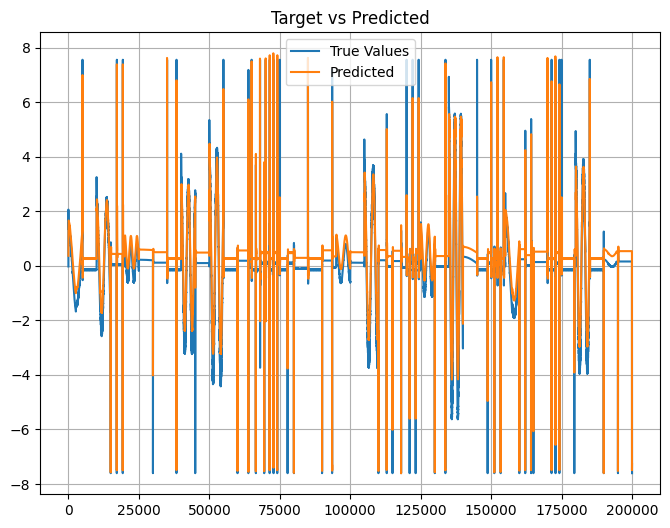

In [114]:
# Plot target vs predicted
plt.figure(figsize=(8, 6))
plt.plot(target_data.cpu().numpy(), label='True Values')
plt.plot(pred.cpu().numpy(), label='Predicted')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()